In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the dataset
data = pd.read_csv('cars.csv')

print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sales in Thousands      100 non-null    float64
 1   Year Resale Value       100 non-null    float64
 2   Price in Thousands      100 non-null    float64
 3   Engine Size             100 non-null    float64
 4   Horsepower              100 non-null    int64  
 5   Wheelbase               100 non-null    float64
 6   Width                   100 non-null    float64
 7   Length                  100 non-null    float64
 8   Curb Weight             100 non-null    float64
 9   Fuel Capacity           100 non-null    float64
 10  Fuel Efficiency         100 non-null    int64  
 11  Power Perf Factor       100 non-null    float64
 12  Vehicle Type Car        100 non-null    int64  
 13  Vehicle Type Passenger  100 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 11.1

In [3]:
# Preprocessing
# Handle missing values (if any)
data.dropna(inplace=True)


# Split into features and target variables
X = data.drop(['Price in Thousands', 'Horsepower'], axis=1)
y = data[['Price in Thousands', 'Horsepower']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [4]:
class MultivariateRegression:
    def __init__(self, learning_rate=0.01, n_iterations=500):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        _, n_outputs = y.shape  # Number of output variables
        cost_list = []
        
        self.weights = np.zeros((n_features, n_outputs))
        self.bias = np.zeros((1, n_outputs))
        
        for i in range(self.n_iterations):
            y_predicted = np.dot(X, self.weights) + self.bias
            
            cost = (1/(2*n_outputs))*np.sum(np.square(y_predicted - y))
            
            # Gradient descent
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y, axis=0)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * np.array(db).reshape(1, -1)
            
            cost_list.append(cost)
            
            if(i % 100 == 0):
                print("Cost: ", cost)
                
        return cost_list
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Initialize and train the model
model = MultivariateRegression()
C = model.fit(X_train, y_train)

Cost:  Price in Thousands     10075.405075
Horsepower            584542.000000
dtype: float64


c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Cost:  Price in Thousands     1302.678870
Horsepower            77886.242122
dtype: float64
Cost:  Price in Thousands      260.704713
Horsepower            13522.979174
dtype: float64
Cost:  Price in Thousands     109.517155
Horsepower            3729.996518
dtype: float64
Cost:  Price in Thousands      82.620325
Horsepower            1858.996918
dtype: float64


In [5]:
def plot_predictions(y_true, y_pred, title):
    plt.scatter(y_true, y_pred)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title)
    plt.show()

y_pred_test = model.predict(X_test)

In [6]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


#mse = np.mean((y_test - y_pred_test) ** 2)
mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

#print(mape)


mse = mean_squared_error(y_test, y_pred_test)
print("Mean Squared Error (MSE):", mse)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred_test)
print("Mean Absolute Error (MAE):", mae)

# Calculate R-squared (R2)
r2 = r2_score(y_test, y_pred_test)
print("R-squared (R2):", r2)

accuracy_mape = 100 - mape
accuracy_r2 = r2 * 100

print(accuracy_mape)
print(accuracy_r2)

Mean Squared Error (MSE): 41.76851970703077
Mean Absolute Error (MAE): 3.9260450339669455
R-squared (R2): 0.9379359529031639
95.07554374948784
93.79359529031639


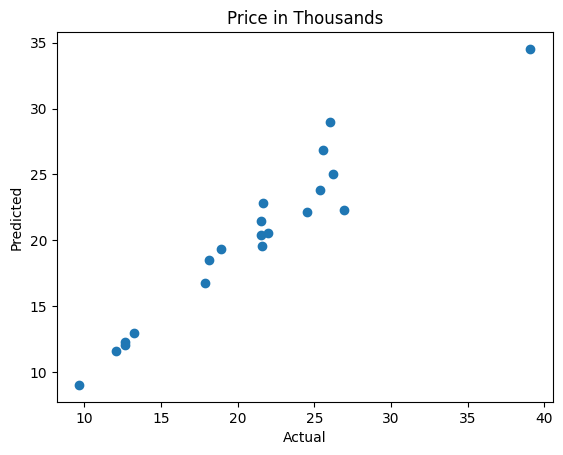

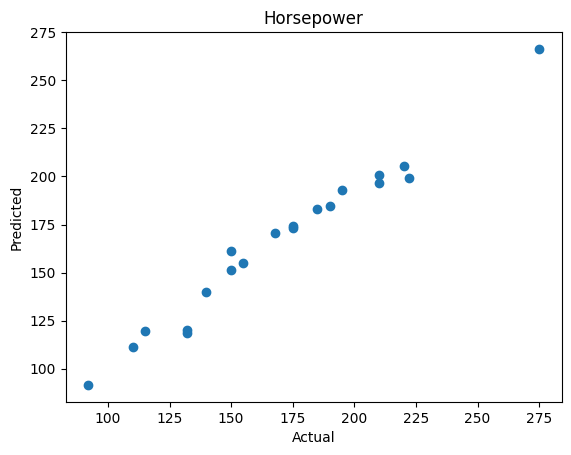

In [7]:
# Plot predicted vs actual values for Price in Thousands
plot_predictions(y_test.iloc[:, 0], y_pred_test[:, 0], 'Price in Thousands')

# Plot predicted vs actual values for Horsepower
plot_predictions(y_test.iloc[:, 1], y_pred_test[:, 1], 'Horsepower')

c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Cost:  Price in Thousands     10566.364053
Horsepower            614257.750000
dtype: float64
Cost:  Price in Thousands     1269.738751
Horsepower            76210.006246
dtype: float64
Cost:  Price in Thousands      250.467803
Horsepower            12922.252489
dtype: float64
Cost:  Price in Thousands     106.363424
Horsepower            3366.174945
dtype: float64
Cost:  Price in Thousands      81.446713
Horsepower            1544.140694
dtype: float64
Cost:  Price in Thousands     10130.339413
Horsepower            603474.000000
dtype: float64
Cost:  Price in Thousands     1296.972328
Horsepower            76034.926283
dtype: float64
Cost:  Price in Thousands      243.186856
Horsepower            12321.787568
dtype: float64
Cost:  Price in Thousands      91.528755
Horsepower            3218.247606
dtype: float64
Cost:  Price in Thousands      66.276273
Horsepower            1647.896135
dtype: float64
Cost:  Price in Thousands     10075.405075
Horsepower            584542.000000
dtype

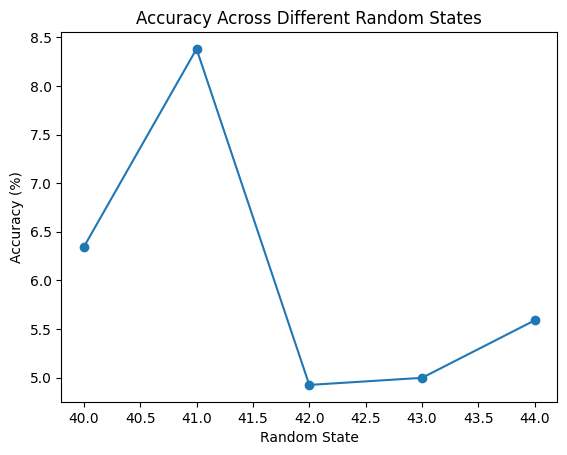

In [8]:
# Accuracy across different random states
random_states = range(40, 45)
accuracies = []

for state in random_states:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=state)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    accuracies.append(accuracy)

plt.plot(random_states, accuracies, marker='o')
plt.xlabel('Random State')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Across Different Random States')
plt.show()

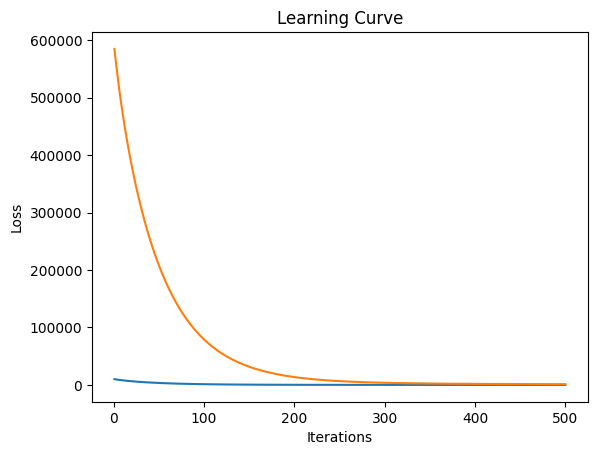

In [9]:
# Learning curve
n_samples, _ = X_train.shape
iterations = range(1, model.n_iterations+1)

plt.plot(iterations, C)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.show()

In [10]:
# Implement K-Fold Cross-Validation
def k_fold_cross_validation(model, X, y, k=5):
    fold_size = len(X) // k
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    mse_scores = []
    mae_scores = []
    
    for i in range(k):
        val_indices = indices[i*fold_size:(i+1)*fold_size]
        train_indices = np.concatenate([indices[:i*fold_size], indices[(i+1)*fold_size:]])
        
        X_train, X_val = X.iloc[train_indices], X.iloc[val_indices]
        y_train, y_val = y.iloc[train_indices], y.iloc[val_indices]
        
        model.fit(X_train, y_train)
        y_pred_val = model.predict(X_val)
        
        mse = np.mean((y_val - y_pred_val) ** 2)
        mae = np.mean(np.abs(y_val - y_pred_val))

        mse_scores.append(mse)
        mae_scores.append(mae)
    
    return mse_scores, mae_scores

In [11]:
import warnings
warnings.filterwarnings('ignore')

In [12]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultivariateRegression(learning_rate=0.00001, n_iterations=700)
mean_mse, mean_mae = k_fold_cross_validation(model, X_train_full, y_train_full, k=5)

print("Mean MSE from K-Fold Cross-Validation:", np.mean(mean_mse))
print("Mean MAE from K-Fold Cross-Validation:", np.mean(mean_mae))

Cost:  Price in Thousands      8123.569077
Horsepower            472100.000000
dtype: float64
Cost:  Price in Thousands      400.177884
Horsepower            11473.270396
dtype: float64
Cost:  Price in Thousands     301.533973
Horsepower            7212.063620
dtype: float64
Cost:  Price in Thousands     240.312024
Horsepower            4591.709638
dtype: float64
Cost:  Price in Thousands     202.045376
Horsepower            2977.935414
dtype: float64
Cost:  Price in Thousands     177.897510
Horsepower            1982.632681
dtype: float64
Cost:  Price in Thousands     162.440082
Horsepower            1367.398754
dtype: float64
Cost:  Price in Thousands      8224.939006
Horsepower            473216.250000
dtype: float64
Cost:  Price in Thousands      390.890492
Horsepower            10743.310046
dtype: float64
Cost:  Price in Thousands     299.896788
Horsepower            7008.732935
dtype: float64
Cost:  Price in Thousands     241.064011
Horsepower            4619.876004
dtype: float6

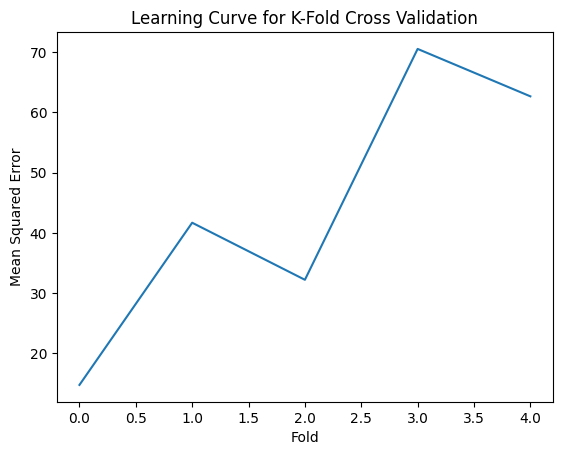

In [13]:
plt.plot(mean_mse)
plt.xlabel('Fold')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve for K-Fold Cross Validation')
plt.show()

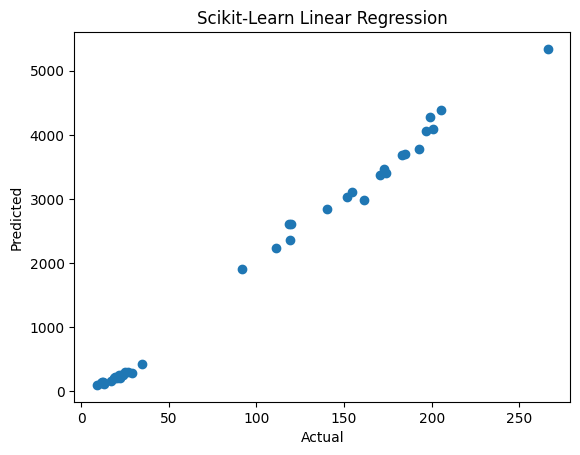

Custom Implementation Mean Error: 44.36345908006706
Scikit-Learn Mean Error: 5.600118254319817


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Fit the model
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_predictions = sk_model.predict(X_test)

# Compare predictions
plt.scatter(y_pred_test, sk_predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Scikit-Learn Linear Regression")
plt.show()

# K-Fold Cross Validation
scores = cross_val_score(sk_model, X, y, cv=5, scoring='neg_mean_squared_error')
mean_score = -np.mean(scores)

print(f"Custom Implementation Mean Error: {np.mean(mean_mse)}")
print(f"Scikit-Learn Mean Error: {mean_score}")
